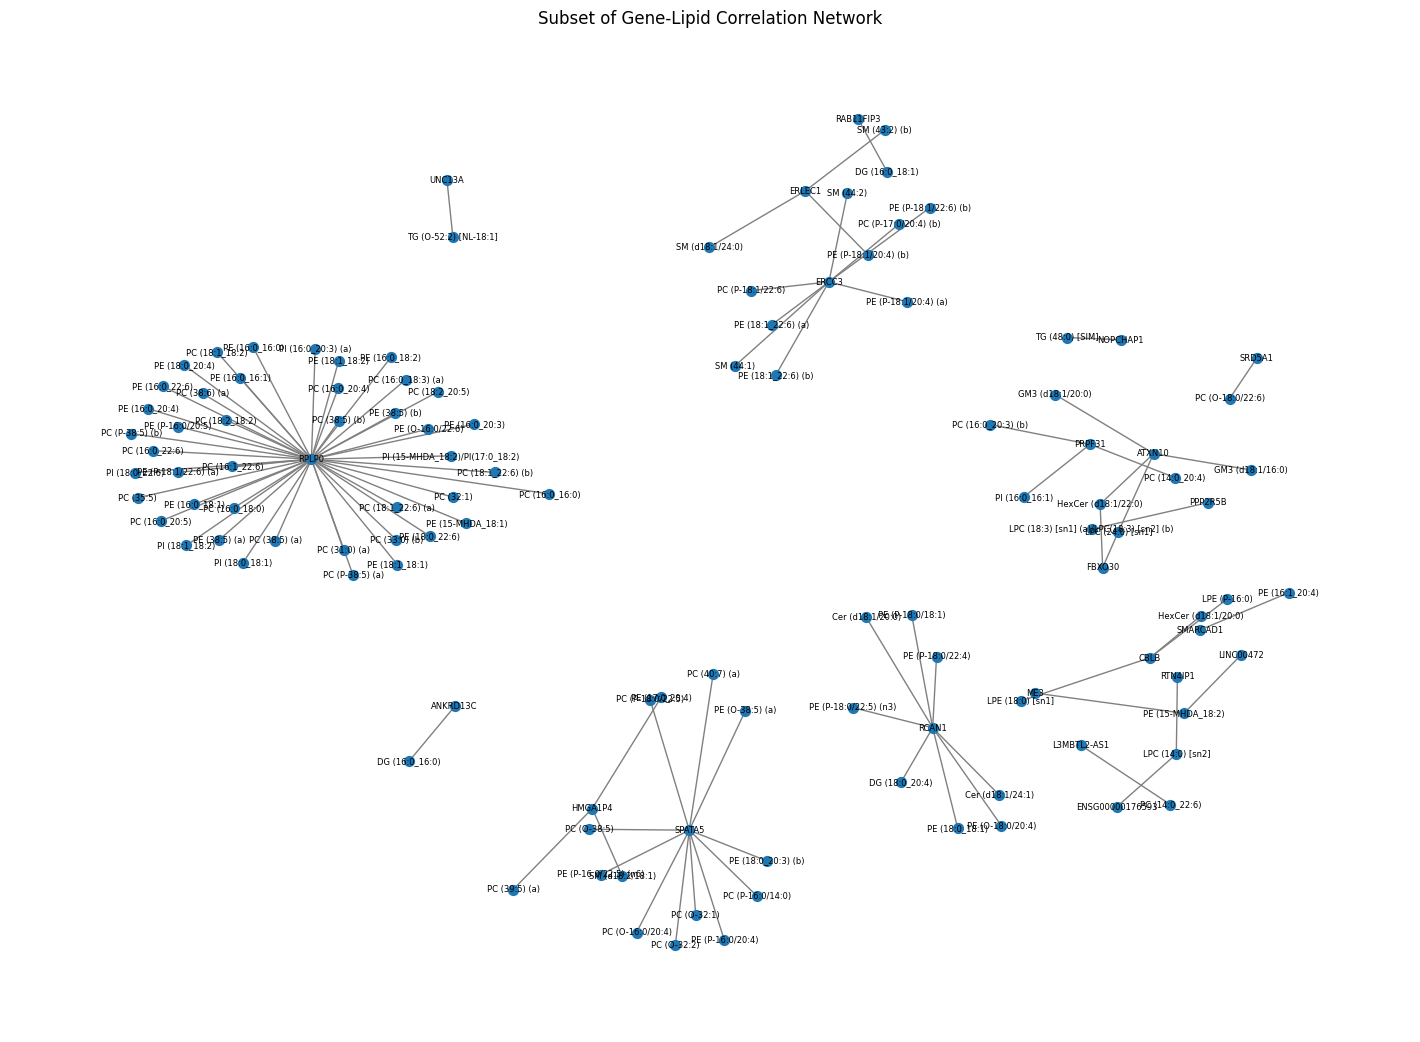

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata
import networkx as nx

# Use the final selected input files
rna_seq_file = 'rna_mapped_for_Correlation_computation_all.csv'
lipidomics_file = 'lipids_mapped_for_Correlation_computation_all.csv'

# Read and preprocess
sc_rna_data = pd.read_csv(rna_seq_file, index_col=0)
lipidomics_data = pd.read_csv(lipidomics_file, index_col=0)

# Transpose so rows = features (genes/lipids), columns = samples
sc_rna_data_t = sc_rna_data.T
lipidomics_data_t = lipidomics_data.T

# Ensure matching sample names
common_samples = sc_rna_data_t.columns.intersection(lipidomics_data_t.columns)
sc_rna_data_t = sc_rna_data_t[common_samples]
lipidomics_data_t = lipidomics_data_t[common_samples]

# Use all genes and lipids
sc_rna_filtered = sc_rna_data_t

# Rank transformation
sc_rna_ranked = sc_rna_filtered.apply(rankdata, axis=1, result_type='broadcast')
lipidomics_ranked = lipidomics_data_t.apply(rankdata, axis=1, result_type='broadcast')

# Convert to float for normalization
gene_array = sc_rna_ranked.to_numpy(dtype=np.float64)
lipid_array = lipidomics_ranked.to_numpy(dtype=np.float64)

# Normalize
gene_array -= gene_array.mean(axis=1, keepdims=True)
lipid_array -= lipid_array.mean(axis=1, keepdims=True)

# Compute Spearman correlation matrix
corr_matrix = np.dot(gene_array, lipid_array.T) / (
    np.linalg.norm(gene_array, axis=1, keepdims=True) * np.linalg.norm(lipid_array, axis=1)
)

# Create DataFrame
correlation_df = pd.DataFrame(corr_matrix, index=sc_rna_ranked.index, columns=lipidomics_ranked.index)

# Flatten the matrix to long-form
flat_corrs = correlation_df.stack().reset_index()
flat_corrs.columns = ['Gene', 'Lipid', 'Correlation']

# Compute top 1 percentile threshold
threshold = np.percentile(abs(flat_corrs['Correlation']), 99)

# Filter top 1% correlations
top_1_percent_df = flat_corrs[abs(flat_corrs['Correlation']) >= threshold].sort_values(by='Correlation', ascending=False)

# Convert to wide format to match provided CSV format
wide_df = top_1_percent_df.pivot(index='Gene', columns='Lipid', values='Correlation')
wide_df = wide_df.sort_index().sort_index(axis=1)
wide_df = wide_df.reset_index()
wide_df.rename(columns={'index': 'Unnamed: 0'}, inplace=True)

# Save final wide format matching the shared CSV
wide_output_path = "Top1Percent_Genes_All_Lipids_Correlations.csv"
wide_df.to_csv(wide_output_path, index=False)

# Save Cytoscape-compatible file (GraphML)
edges = list(top_1_percent_df.itertuples(index=False, name=None))
G = nx.Graph()
G.add_weighted_edges_from(edges)
nx.write_graphml(G, "Top1Percent_Genes_All_Lipids_Network.graphml")

# Show final confirmation
print(f"Saved wide format matrix to {wide_output_path}")
print("Saved Cytoscape-compatible network to Top1Percent_Genes_All_Lipids_Network.graphml")
